# Interpretabilidade Local com SHAP (KernelExplainer)\n
Baseado no tutorial oficial do SHAP para modelos Keras, este notebook foca na **Interpretabilidade Local**. Em vez de olhar para o modelo inteiro de uma vez, vamos pegar o exato momento de um único motor e perguntar ao SHAP: *Por que a Rede Neural previu que este motor específico vai quebrar em X voos?*

In [24]:
import os
import h5py
import gc
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

import tensorflow as tf
from tensorflow.keras.models import load_model

# Inicializa o javascript do SHAP para os gráficos interativos (Force Plot)
shap.initjs()

plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

## 1. Carregamento dos Dados e Modelo

In [25]:
filename = '../data/N-CMAPSS_DS02-006.h5'
if not os.path.exists(filename):
    filename = 'data/N-CMAPSS_DS02-006.h5'

with h5py.File(filename, 'r') as hdf:
    W_test = np.array(hdf.get('W_test'))
    X_s_test = np.array(hdf.get('X_s_test'))
    Y_test = np.array(hdf.get('Y_test'))
    A_test = np.array(hdf.get('A_test'))
    
    W_var = [v.decode('utf-8') for v in np.array(hdf.get('W_var'))]
    X_s_var = [v.decode('utf-8') for v in np.array(hdf.get('X_s_var'))]

base_names = W_var + X_s_var
feature_names = [f"{name}_raw" for name in base_names] + \
                [f"{name}_mean" for name in base_names] + \
                [f"{name}_var" for name in base_names]

def create_temporal_features_safe(W, X_s, Y, A, window):
    matriz_base = np.concatenate((W, X_s), axis=1).astype('float32')
    df = pd.DataFrame(matriz_base)
    df['unit'] = A[:, 0].astype('float32')
    df['RUL'] = Y.flatten().astype('float32')

    df_mean = df.groupby('unit').rolling(window=window, min_periods=1).mean().reset_index(level=0, drop=True).sort_index().astype('float32')
    df_var = df.groupby('unit').rolling(window=window, min_periods=1).var().fillna(0).reset_index(level=0, drop=True).sort_index().astype('float32')

    df_mean = df_mean[df.columns[:-2]]
    df_var = df_var[df.columns[:-2]]
    df_raw = pd.DataFrame(matriz_base)

    X_temporal = pd.concat([df_raw, df_mean, df_var], axis=1).values.astype('float32')
    y_labels = df['RUL'].values.astype('float32')

    del df, df_mean, df_var, df_raw, matriz_base
    gc.collect()

    return X_temporal, y_labels

MODEL_FOLDER = 'model2'
WINDOW_SIZE = 20 

model = load_model(os.path.join(MODEL_FOLDER, 'model.keras'))
scaler = joblib.load(os.path.join(MODEL_FOLDER, 'scaler.pkl'))

X_test_raw, y_test_labels = create_temporal_features_safe(W_test, X_s_test, Y_test, A_test, window=WINDOW_SIZE)
X_test_scaled = scaler.transform(X_test_raw).astype('float32')

df_X_test = pd.DataFrame(X_test_scaled, columns=feature_names)

/home/anderson/miniconda3/envs/intelligent_systems/lib/python3.11/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


## 2. Preparando a Função Wrapper e o KernelExplainer\n
Conforme o tutorial oficial, o SHAP `KernelExplainer` espera que o modelo receba um array 2D e devolva um vetor 1D. Vamos criar uma função `f(X)` para encapsular o `.predict()` do Keras.

In [26]:
# Wrapper exigido pelo SHAP KernelExplainer para modelos Keras
def f(X):
    # O modelo prevê e a gente "achata" a resposta para 1D
    return model.predict(X, verbose=0).flatten()

# Background de 50 amostras (como no tutorial do Census)
#ackground_data = df_X_test.iloc[:50, :]
background_data = shap.kmeans(df_X_test, 50)

print("Inicializando o KernelExplainer...")
# Usamos o KernelExplainer, que é agnóstico e perfeitamente estável para funções genéricas
kernel_explainer = shap.KernelExplainer(f, background_data)

Inicializando o KernelExplainer...


## 3. Explicando uma Predição Única (Local Interpretability)\n
Vamos selecionar uma única linha do nosso conjunto de teste (ex: a linha 299). O modelo fará a previsão de RUL para essa linha, e o SHAP vai decompor matematicamente quais variáveis empurraram o RUL para cima ou para baixo a partir do valor base.

In [27]:
# ------------------------------------------------------------------
# CÉLULA 1: Calcular os valores (Pode substituir o código atual da Seção 3 por este)
# ------------------------------------------------------------------
# Selecionando uma instância para explicar
linha = 299
instancia = df_X_test.iloc[linha:linha+1, :]
rul_real = y_test_labels[linha]
rul_previsto = f(instancia.values)[0]

print(f"RUL Real do Motor: {rul_real}")
print(f"RUL Previsto pelo Modelo: {rul_previsto:.2f}")

print("\nCalculando SHAP para a instância")
# Usa o método tradicional seguro do tutorial
shap_values_raw = kernel_explainer.shap_values(instancia,)

# Criamos o objeto "Explanation" manualmente para não dar bug nos gráficos novos
shap_obj = shap.Explanation(
    values=shap_values_raw[0], # Os pesos que empurram o RUL
    base_values=kernel_explainer.expected_value, # De onde a conta começa
    data=instancia.values[0], # Os valores reais dos sensores naquele momento
    feature_names=feature_names
)


RUL Real do Motor: 58.0
RUL Previsto pelo Modelo: 63.69

Calculando SHAP para a instância


  0%|          | 0/1 [00:00<?, ?it/s]

### 3.1 Waterfall Plot\n
O Gráfico de Cachoeira mostra a 'soma' das decisões. Ele parte do valor médio global esperado pelo modelo (no eixo X inferior) e vai somando ou subtraindo os impactos das features (em vermelho ou azul) até chegar na previsão final desta instância.

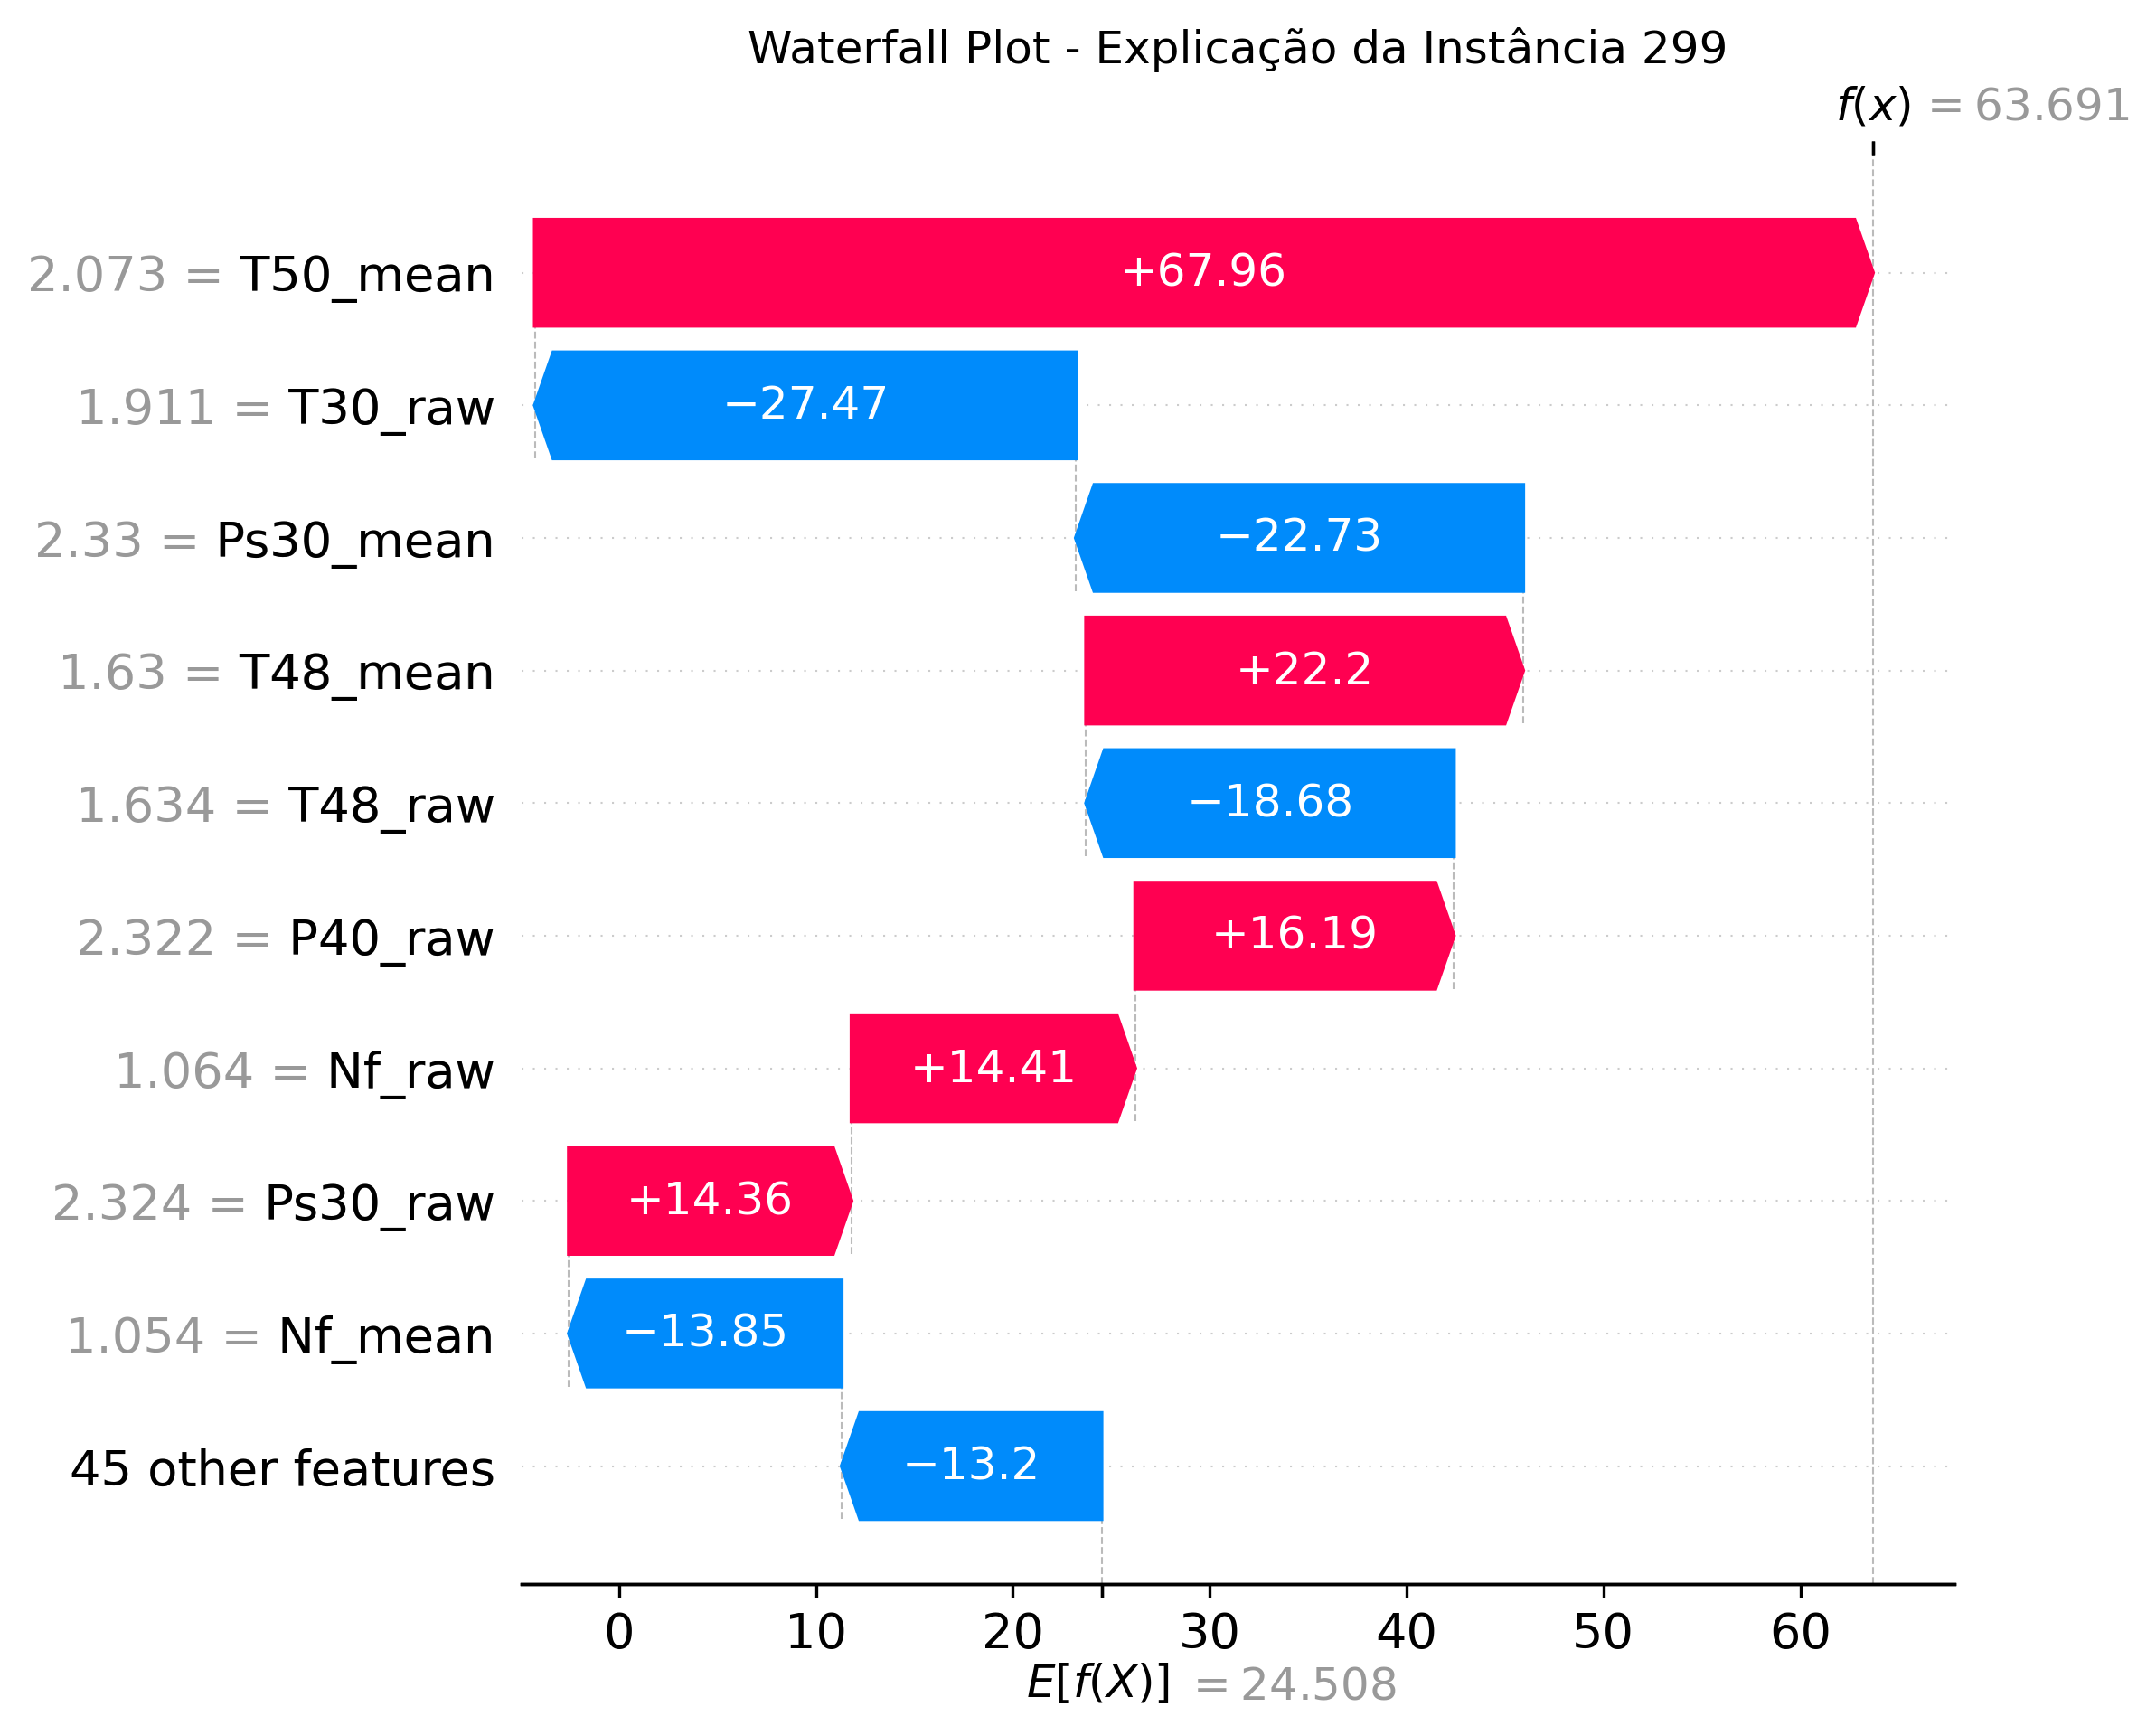

In [28]:
# ------------------------------------------------------------------
# CÉLULA 2: Gráfico Waterfall
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5))
shap.plots.waterfall(shap_obj, show=False)
plt.title(f"Waterfall Plot - Explicação da Instância {linha}")
plt.tight_layout()
plt.savefig('fig_shap_waterfall.png')
plt.show()


### 3.2 Force Plot\n
O Gráfico de Força condensa a mesma informação em uma única linha interativa, muito útil para colocar abaixo de previsões em dashboards em tempo real.

In [29]:
# ------------------------------------------------------------------
# CÉLULA 3: Gráfico Force Plot
# ------------------------------------------------------------------
# O Force Plot usa os arrays crus tradicionais
shap.force_plot(
    kernel_explainer.expected_value, 
    shap_values_raw[0], 
    instancia.round(2) # Arredonda para não ficar um número gigante no balãozinho
)


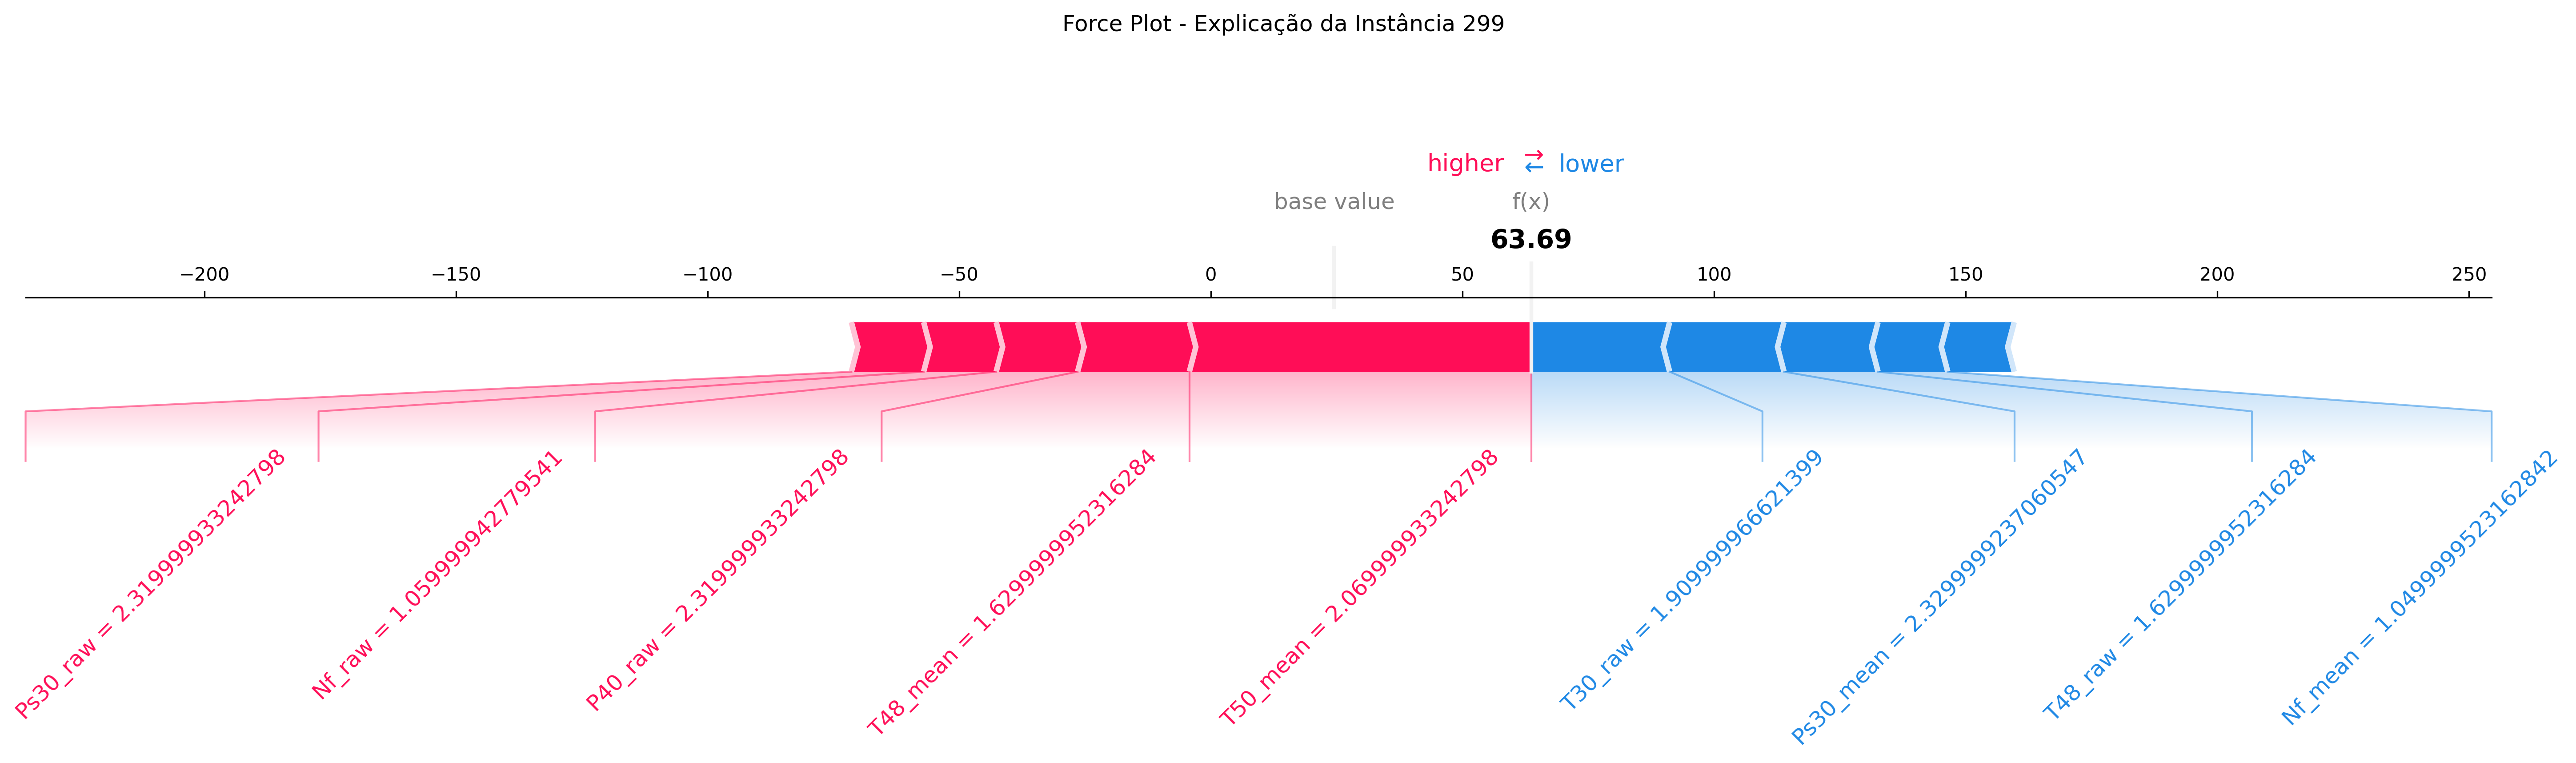

In [32]:
# ------------------------------------------------------------------
# CÉLULA 3: Gráfico Force Plot Estático (Corrigido Definitivo)
# ------------------------------------------------------------------
import numpy as np

# Arredondamos os valores mantendo eles como números (para o SHAP não travar)
instancia_arredondada = np.round(instancia.values[0], 2)

shap.force_plot(
    kernel_explainer.expected_value, 
    shap_values_raw[0], 
    instancia_arredondada, 
    feature_names=feature_names, 
    matplotlib=True, 
    show=False,
    figsize=(20, 5),             # Estica o gráfico para a tela toda
    text_rotation=45,            # Inclina os textos em 45 graus para não encavalar
    contribution_threshold=0.1   # O SEGREDO: Só escreve quem alterou a vida do motor em > 10%
)

# O SHAP cria uma figura própria por baixo dos panos, então "puxamos" ela
fig = plt.gcf()
fig.suptitle(f"Force Plot - Explicação da Instância {linha}")

plt.tight_layout()
plt.savefig('fig_shap_forceplot.png', bbox_inches='tight', dpi=300)
plt.show()
